In [12]:
# !pip install PyWavelets
# !pip install mahotas
import cv2
import numpy as np
import mahotas
import pywt
from matplotlib import pyplot as plt

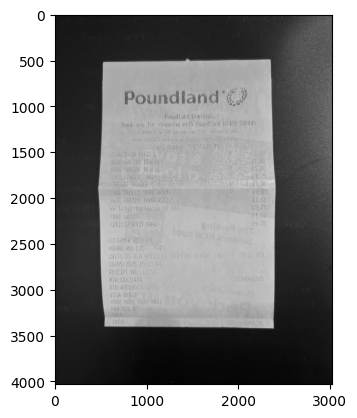

In [2]:
og_receipt = cv2.imread('D:\DIP\Project\Final\Poundland.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imwrite('D:\DIP\Project\Final\img_p\og_receipt.jpg', og_receipt)
plt.imshow(og_receipt, cmap='gray')
plt.show()

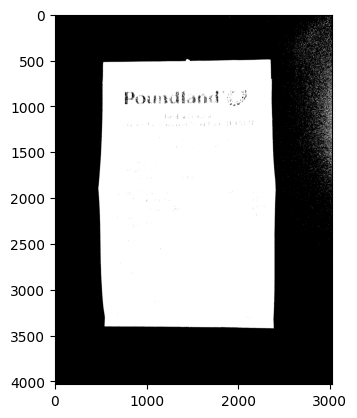

Otsu Threshold = 107


In [3]:
#แยกใบเสร็จกับพื้นหลังด้วย Otsu
# _, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
T = mahotas.thresholding.otsu(og_receipt)
mask = np.where(og_receipt > T, 255, 0).astype(np.uint8)
cv2.imwrite('D:\DIP\Project\Final\img_p\mask.jpg', mask)
plt.imshow(mask, cmap='gray')
plt.show()
print(f"Otsu Threshold = {T}")

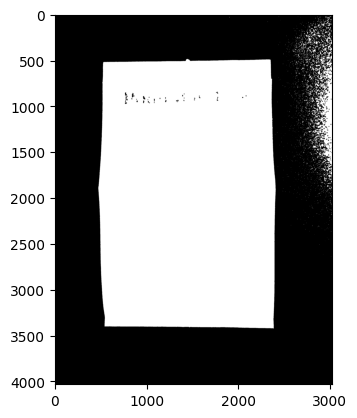

In [4]:
kernel = np.ones((7, 7), np.uint8)
mask = mahotas.close(mask, kernel)
cv2.imwrite('D:\DIP\Project\Final\img_p\mask2.jpg', mask)
plt.imshow(mask, cmap='gray')
plt.show()

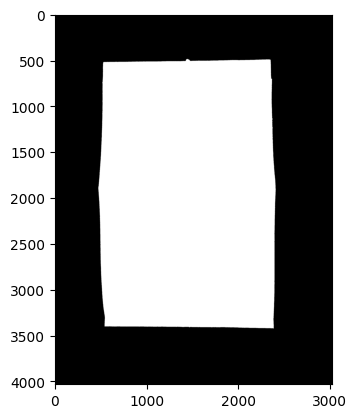

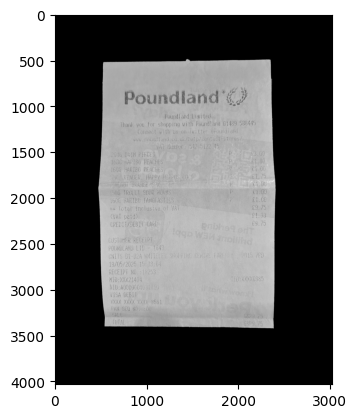

In [5]:
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest = max(contours, key=cv2.contourArea)

#สร้าง Mask ทึบเฉพาะบริเวณใบเสร็จและนำไปซ้อนกับภาพเดิมเพื่อตัดส่วนเกินรอบนอกออก
final_mask = np.zeros_like(og_receipt)
cv2.drawContours(final_mask, [largest], -1, 255, -1)

masked = cv2.bitwise_and(og_receipt, og_receipt, mask=final_mask)

cv2.imwrite('D:\DIP\Project\Final\img_p\maskF.jpg', final_mask)
cv2.imwrite('D:\DIP\Project\Final\img_p\masked.jpg', masked)
plt.imshow(final_mask, cmap='gray')
plt.show()
plt.imshow(masked, cmap='gray')
plt.show()

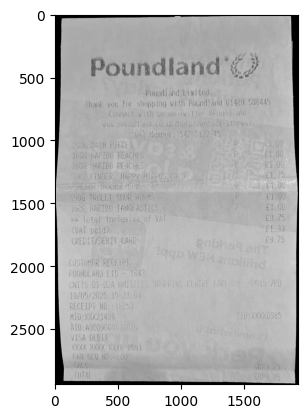

In [6]:
#Crop ให้เหลือเฉพาะขอบเขตของใบเสร็จ
x, y, w, h = cv2.boundingRect(largest)
cropped = masked[y:y + h, x:x + w]
cv2.imwrite('D:\DIP\Project\Final\img_p\cropped.jpg', cropped)
plt.imshow(cropped, cmap='gray')
plt.show()

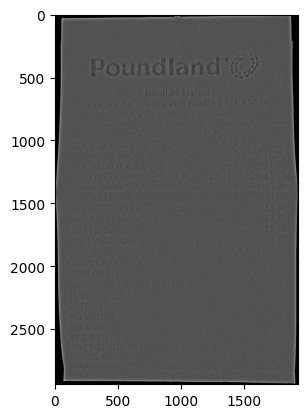

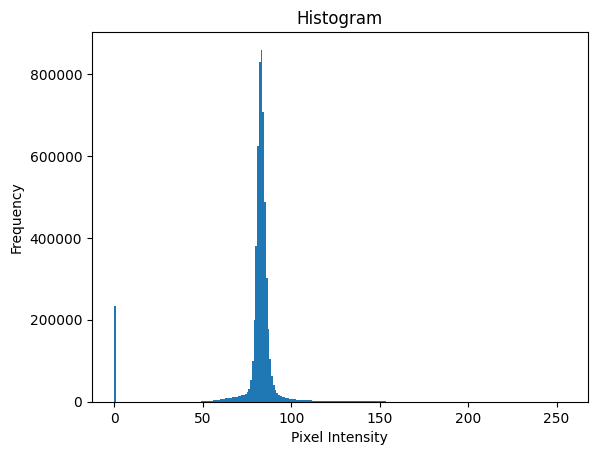

In [14]:
#ทำ Background Division เพื่อกำจัดแสงเงาที่ไม่สม่ำเสมอและปัญหาข้อความทะลุหลัง
#ทำ Gaussian Blur ขนาดใหญ่เพื่อประมาณค่าความสว่างของพื้นหลัง
bg = cv2.GaussianBlur(cropped.astype(np.float32), (91, 91), 0) #นำภาพมาหารด้วยพื้นหลังเพื่อปรับค่าความสว่างให้สม่ำเสมอทั่วทั้งภาพ
divided = cropped.astype(np.float32) / (bg + 1e-6) #กันหารด้วยศูนย์ เก็บค่าได้กว้างกว่า
divided = cv2.normalize(divided, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
cv2.imwrite('D:\DIP\Project\Final\img_p\divided.jpg', divided)
plt.imshow(divided, cmap='gray')
plt.show()

plt.figure()
plt.hist(divided.ravel(), bins=256)
plt.title("Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

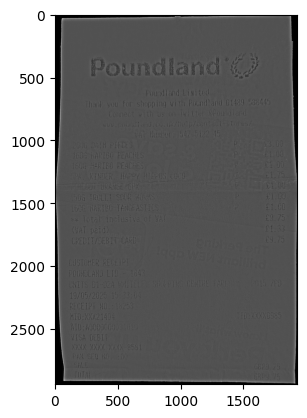

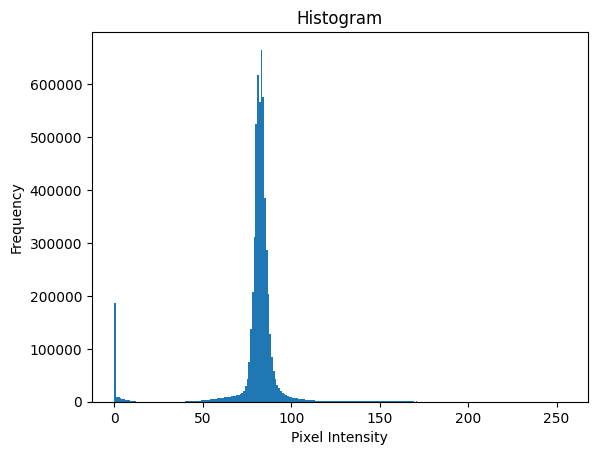

In [19]:
#Wavelet Sharpen เพิ่มความคมชัดขอบตัวอักษร
img_float = divided.astype(np.float32) / 255.0
#Wavelet decomposition
coeffs = pywt.wavedec2(img_float, wavelet='db4', level=3)
new_coeffs = [coeffs[0]]
for detail in coeffs[1:]:
    cH, cV, cD = detail
    cH = cH * 1.5
    cV = cV * 1.5
    cD = cD * 1.2
    new_coeffs.append((cH, cV, cD))

sharp = pywt.waverec2(new_coeffs, 'db4')
sharp = np.clip(sharp, 0, 1)
sharp = (sharp * 255).astype(np.uint8)
warped = sharp
cv2.imwrite('D:\DIP\Project\Final\img_p\warped.jpg', warped)
plt.imshow(warped, cmap='gray')
plt.show()

plt.figure()
plt.hist(warped.ravel(), bins=256)
plt.title("Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

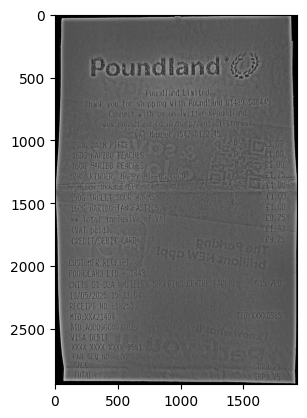

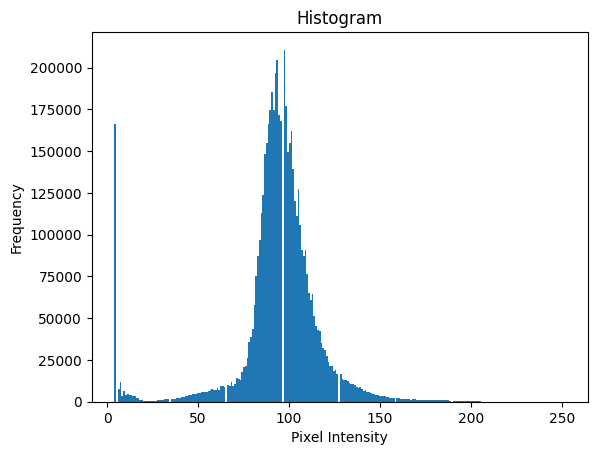

In [9]:
#ลด noise เล็กๆ ด้วย Gaussian Blur
blurred = cv2.GaussianBlur(warped, (3, 3), 0)
#CLAHE เพิ่มความคมชัดของตัวอักษรด้วย (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
cl = clahe.apply(blurred)
cv2.imwrite('D:/DIP/Project/Final/output_Pre_Poundland.jpg', cl)
plt.imshow(cl, cmap='gray')
plt.show()

plt.figure()
plt.hist(cl.ravel(), bins=256)
plt.title("Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

In [10]:
from OCR_Paddle import run_ocr_pipeline
from OCR_Evaluate import calculate_metrics

INPUT_IMAGE = "D:/DIP/Project/Final/Poundland.jpg" #ภาพต้นฉบับ
PREPROCESSED_IMG = "D:/DIP/Project/Final/output_Pre_Poundland.jpg" #ภาพต้นฉบับที่ผ่าน image processing แล้ว
OCR_OUTPUT_PRE = "D:/DIP/Project/Final/output_Pre_OCR_Poundland.jpg" #ภาพที่ผ่าน image processing แล้ว ไปเข้า OCRต่อ
OCR_OUTPUT_ORI = "D:/DIP/Project/Final/output_Ori_OCR_Poundland.jpg" #ภาพต้นฉบับที่ผ่าน OCR
GROUND_TRUTH_TXT = "D:/DIP/Project/Final/ground_truth.txt" #ผลเฉลย

In [11]:
# อ่านไฟล์ groud truth
with open("D:/DIP/Project/Final/ground_truth.txt", 'r', encoding='utf-8') as f: #เปิดไฟล์แบบปลอดภัย
    gt_text = f.read()

# ทำ OCR ภาพ
text_ori = run_ocr_pipeline(INPUT_IMAGE, OCR_OUTPUT_ORI, 270)
text_pre = run_ocr_pipeline(PREPROCESSED_IMG, OCR_OUTPUT_PRE)

# สรุปผลการเปรียบเทียบ
cer_pre, wer_pre = calculate_metrics(gt_text, text_pre)
cer_ori, wer_ori = calculate_metrics(gt_text, text_ori)

print("=" * 50)
print(f"{'Metric':<15} | {'Original':<15} | {'Preprocessed':<15}")
print("-" * 50)
print(f"{'CER':<15} | {cer_ori * 100:>13.2f}% | {cer_pre * 100:>13.2f}%")
print(f"{'WER':<15} | {wer_ori * 100:>13.2f}% | {wer_pre * 100:>13.2f}%")
print("=" * 50)

Metric          | Original        | Preprocessed   
--------------------------------------------------
CER             |         27.65% |         22.06%
WER             |         70.59% |         68.63%
